In [1]:
# Google Drive mount is optional. Uploaded Colab files in /content also work.
import sys
if 'google.colab' in sys.modules:
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
    except Exception as exc:
        print('Drive mount skipped:', exc)
else:
    print('Local Jupyter environment')

Local Jupyter environment


### Import Libraries

In [2]:
import os
import sys
import csv
import gc
import hashlib
import json
import math
import random
import re
import time
import warnings
import zipfile
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.model_selection import StratifiedGroupKFold
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    ConvNeXt_Tiny_Weights, ResNet50_Weights, convnext_tiny, resnet50,
)
from torchvision.transforms import InterpolationMode, functional as TF

In [3]:
# Locate dataset.zip and result.csv without assuming another person's path.
def find_required_file(names):
    names = {name.lower() for name in names}
    direct_roots = [Path.cwd(), Path('/content')]
    for root in direct_roots:
        if root.exists():
            for name in names:
                candidate = root / name
                if candidate.is_file():
                    return candidate.resolve()
    drive_root = Path('/content/drive/MyDrive')
    if drive_root.exists():
        matches = [p for p in drive_root.rglob('*') if p.is_file() and p.name.lower() in names]
        if matches:
            return sorted(matches, key=lambda p: (len(p.parts), str(p)))[0].resolve()
    raise FileNotFoundError(f'Could not find one of: {sorted(names)}')

DATA_ZIP = find_required_file({'dataset.zip'})
TEMPLATE_CSV = find_required_file({'result.csv', 'results.csv'})
PROJECT_ROOT = DATA_ZIP.parent
os.chdir(PROJECT_ROOT)
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_ZIP:', DATA_ZIP)
print('TEMPLATE_CSV:', TEMPLATE_CSV)

PROJECT_ROOT: C:\Users\삼성\Desktop\project1_DL
DATA_ZIP: C:\Users\삼성\Desktop\project1_DL\dataset.zip
TEMPLATE_CSV: C:\Users\삼성\Desktop\project1_DL\result.csv


In [4]:
def set_seed(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

### Loading the Dataset

In [5]:
def find_train_test(root):
    root = Path(root)
    for train in root.rglob('*') if root.exists() else []:
        if train.is_dir() and train.name.lower() == 'train':
            siblings = {p.name.lower(): p for p in train.parent.iterdir() if p.is_dir()}
            if 'test' in siblings:
                return train.resolve(), siblings['test'].resolve()
    return None

def safe_unzip(zip_filename, extract_path):
    ready = find_train_test(extract_path)
    if ready is not None:
        print('Dataset already extracted:', extract_path)
        return ready
    extract_path = Path(extract_path)
    extract_path.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_filename, 'r') as archive:
        archive.extractall(extract_path)
    ready = find_train_test(extract_path)
    if ready is None:
        raise RuntimeError('Train/Test directories were not found after extraction')
    print('Dataset extracted:', extract_path)
    return ready

DATA_DIR = PROJECT_ROOT / 'dataset_extracted'
TRAIN_DIR, TEST_DIR = safe_unzip(DATA_ZIP, DATA_DIR)
print('TRAIN_DIR:', TRAIN_DIR)
print('TEST_DIR:', TEST_DIR)

Dataset already extracted: C:\Users\삼성\Desktop\project1_DL\dataset_extracted
TRAIN_DIR: C:\Users\삼성\Desktop\project1_DL\dataset_extracted\data 2\Train
TEST_DIR: C:\Users\삼성\Desktop\project1_DL\dataset_extracted\data 2\Test


Train images: 26010 Classes: 43
Test images: 8670


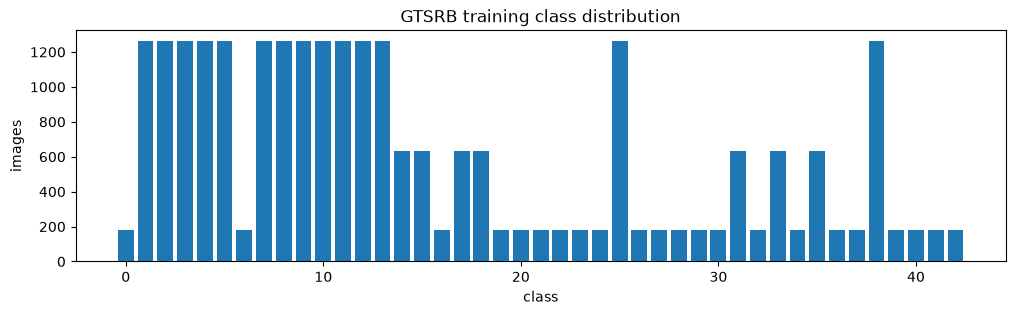

In [6]:
# Skeleton-style lightweight dataset overview (the final model loads images lazily).
num_classes = 43
class_counts = []
for class_id in range(num_classes):
    class_dir = TRAIN_DIR / str(class_id)
    count = sum(p.suffix.lower() in {'.png', '.jpg', '.jpeg', '.ppm', '.bmp'} for p in class_dir.iterdir())
    class_counts.append(count)
print('Train images:', sum(class_counts), 'Classes:', len(class_counts))
print('Test images:', sum(p.suffix.lower() in {'.png', '.jpg', '.jpeg', '.ppm', '.bmp'} for p in TEST_DIR.iterdir()))
plt.figure(figsize=(12, 3))
plt.bar(range(num_classes), class_counts)
plt.title('GTSRB training class distribution')
plt.xlabel('class'); plt.ylabel('images'); plt.show()

---
# Final Model Training and Inference

아래 코드는 외부 Python 파일이나 기존 checkpoint 없이 실행됩니다. torchvision의 ImageNet-1K pretrained weight만 사용하며, TEST label/reference/L1은 사용하지 않습니다.

### Configuration and Track-aware 5-fold

In [7]:
NUM_CLASSES = 43
NUM_FOLDS = 5
SPLIT_SEED = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP = DEVICE.type == 'cuda'
NUM_WORKERS = 4 if sys.platform != 'win32' else 0
OUTPUT_ROOT = PROJECT_ROOT / 'outputs' / 'team1_final_reproduction'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FINAL_CSV = PROJECT_ROOT / 'DS2_challenge_team1_final.csv'
CANONICAL_FOLD_ASSIGNMENT_SHA256 = 'f49b11289facbb81b224dc877d5b26def748d57ad4765f78d2d0589699334ad3'
IMAGE_SUFFIXES = {'.png', '.jpg', '.jpeg', '.ppm', '.bmp'}
TRAIN_RE = re.compile(r'^(?P<class_id>\d+)_(?P<track_id>\d+)_(?P<image_id>\d+)\.(?:png|jpe?g|ppm|bmp)$', re.I)

@dataclass(frozen=True)
class Sample:
    path: Path
    filename: str
    label: int
    track_id: str
    image_id: str
    width: int = -1
    height: int = -1

def natural_key(value):
    return [int(x) if x.isdigit() else x.lower() for x in re.split(r'(\d+)', str(value))]

train_samples = []
for class_dir in sorted((p for p in TRAIN_DIR.iterdir() if p.is_dir()), key=lambda p: int(p.name)):
    label = int(class_dir.name)
    for path in sorted((p for p in class_dir.iterdir() if p.suffix.lower() in IMAGE_SUFFIXES), key=lambda p: natural_key(p.name)):
        match = TRAIN_RE.fullmatch(path.name)
        if match is None or int(match.group('class_id')) != label:
            raise ValueError(f'Invalid training filename: {path}')
        with Image.open(path) as image:
            width, height = image.size
        train_samples.append(Sample(path, path.name, label, match.group('track_id'), match.group('image_id'), width, height))
train_samples = sorted(train_samples, key=lambda s: s.filename)

test_paths = sorted((p for p in TEST_DIR.iterdir() if p.suffix.lower() in IMAGE_SUFFIXES), key=lambda p: natural_key(p.name))
test_samples = [Sample(p, p.name, -1, '', p.stem) for p in test_paths]
labels = np.asarray([s.label for s in train_samples], dtype=np.int64)
groups = np.asarray([f'{s.label}:{s.track_id}' for s in train_samples])
splitter = StratifiedGroupKFold(n_splits=NUM_FOLDS, shuffle=True, random_state=SPLIT_SEED)
fold_ids = np.full(len(train_samples), -1, dtype=np.int64)
for fold, (_, val_idx) in enumerate(splitter.split(np.zeros(len(labels)), labels, groups)):
    fold_ids[val_idx] = fold
    assert not (set(groups[val_idx]) & set(groups[fold_ids != fold]))
assert np.all(fold_ids >= 0)

canonical = ''.join(f'{s.filename},{int(fold)}\n' for s, fold in zip(train_samples, fold_ids))
assignment_sha = hashlib.sha256(canonical.encode()).hexdigest()
assert assignment_sha == CANONICAL_FOLD_ASSIGNMENT_SHA256, assignment_sha
assert len(train_samples) == 26010 and len(test_samples) == 8670
print('device:', DEVICE, 'OOF:', len(train_samples), 'TEST:', len(test_samples))
print('canonical fold assignment SHA-256:', assignment_sha)

device: cuda OOF: 26010 TEST: 8670
canonical fold assignment SHA-256: f49b11289facbb81b224dc877d5b26def748d57ad4765f78d2d0589699334ad3


### Dataset and Transform Definitions

In [8]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

class EnsureRGB:
    def __call__(self, image):
        return image if image.mode == 'RGB' else image.convert('RGB')

class AspectRatioPad:
    def __init__(self, size, fill=0): self.size, self.fill = size, fill
    def __call__(self, image):
        width, height = image.size
        scale = self.size / max(width, height)
        new_width, new_height = max(1, round(width*scale)), max(1, round(height*scale))
        image = TF.resize(image, [new_height, new_width], interpolation=InterpolationMode.BILINEAR)
        horizontal, vertical = self.size-new_width, self.size-new_height
        left, top = horizontal//2, vertical//2
        return TF.pad(image, [left, top, horizontal-left, vertical-top], fill=self.fill)

class FixedRotation:
    def __init__(self, degrees): self.degrees = degrees
    def __call__(self, image): return TF.rotate(image, self.degrees, InterpolationMode.BILINEAR, fill=0)

class FixedBrightness:
    def __init__(self, factor): self.factor = factor
    def __call__(self, image): return ImageEnhance.Brightness(image).enhance(self.factor)

def build_transform(size, train=False, variant=None):
    ops = [EnsureRGB(), AspectRatioPad(size)]
    if train:
        ops += [
            transforms.RandomRotation(10, interpolation=InterpolationMode.BILINEAR, fill=0),
            transforms.RandomAffine(0, translate=(0.06,0.06), scale=(0.92,1.08), interpolation=InterpolationMode.BILINEAR, fill=0),
            transforms.ColorJitter(brightness=0.18, contrast=0.18, saturation=0.12, hue=0.02),
            transforms.RandomPerspective(distortion_scale=0.08, p=0.15, fill=0),
            transforms.RandomApply([transforms.GaussianBlur(3, sigma=(0.1,0.7))], p=0.08),
        ]
    elif variant == 'rotate_-4': ops.append(FixedRotation(-4))
    elif variant == 'rotate_+4': ops.append(FixedRotation(4))
    elif variant == 'brightness': ops.append(FixedBrightness(1.06))
    ops += [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    return transforms.Compose(ops)

class SignDataset(Dataset):
    def __init__(self, samples, transform): self.samples, self.transform = list(samples), transform
    def __len__(self): return len(self.samples)
    def __getitem__(self, index):
        sample = self.samples[index]
        with Image.open(sample.path) as image: image = image.convert('RGB')
        return {'image': self.transform(image), 'label': sample.label, 'filename': sample.filename}

TTA_VARIANTS = (None, 'rotate_-4', 'rotate_+4', 'brightness')
class TTADataset(Dataset):
    def __init__(self, samples, size):
        self.samples = list(samples); self.transforms = [build_transform(size, variant=v) for v in TTA_VARIANTS]
    def __len__(self): return len(self.samples)
    def __getitem__(self, index):
        sample = self.samples[index]
        with Image.open(sample.path) as image: image = image.convert('RGB')
        return {'images': torch.stack([t(image) for t in self.transforms]), 'label': sample.label, 'filename': sample.filename}

def make_loader(dataset, batch_size, shuffle=False):
    generator = torch.Generator().manual_seed(42)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=NUM_WORKERS,
                      pin_memory=DEVICE.type=='cuda', persistent_workers=NUM_WORKERS>0, generator=generator)

### Build and Train the 20 Models

In [9]:
def build_model(name, pretrained):
    if name == 'resnet50':
        model = resnet50(weights=ResNet50_Weights.DEFAULT if pretrained else None)
        model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    elif name == 'convnext_tiny':
        model = convnext_tiny(weights=ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None)
        model.classifier[-1] = nn.Linear(model.classifier[-1].in_features, NUM_CLASSES)
    else: raise ValueError(name)
    return model

def evaluate_model(model, samples, size, batch_size):
    loader = make_loader(SignDataset(samples, build_transform(size)), batch_size)
    probabilities, targets, names = [], [], []
    model.eval()
    with torch.inference_mode():
        for batch in loader:
            images = batch['image'].to(DEVICE, non_blocking=True)
            with torch.autocast(device_type=DEVICE.type, enabled=AMP): logits = model(images)
            probabilities.append(logits.float().softmax(1).cpu().numpy())
            targets.extend(batch['label'].numpy().tolist()); names.extend(batch['filename'])
    return np.concatenate(probabilities), np.asarray(targets), np.asarray(names)

def train_fold(spec):
    checkpoint_path = spec['dir'] / 'best_model.pt'
    if checkpoint_path.exists():
        print('reuse checkpoint:', checkpoint_path); return
    set_seed(42)
    train_idx, val_idx = np.flatnonzero(fold_ids != spec['fold']), np.flatnonzero(fold_ids == spec['fold'])
    train_set = [train_samples[i] for i in train_idx]; val_set = [train_samples[i] for i in val_idx]
    assert not ({f'{s.label}:{s.track_id}' for s in train_set} & {f'{s.label}:{s.track_id}' for s in val_set})
    train_loader = make_loader(SignDataset(train_set, build_transform(spec['size'], train=True)), spec['batch'], True)
    model = build_model(spec['model'], pretrained=True).to(DEVICE)
    criterion = nn.CrossEntropyLoss(); optimizer = AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
    scaler = torch.amp.GradScaler('cuda', enabled=AMP)
    best_f1, stale = -1.0, 0; spec['dir'].mkdir(parents=True, exist_ok=True)
    for epoch in range(1, spec['epochs']+1):
        model.train()
        for batch in tqdm(train_loader, desc=f"{spec['model']} {spec['size']} F{spec['fold']} E{epoch}", leave=False):
            images = batch['image'].to(DEVICE, non_blocking=True); target = batch['label'].to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type=DEVICE.type, enabled=AMP): loss = criterion(model(images), target)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
        prob, target, _ = evaluate_model(model, val_set, spec['size'], spec['batch'])
        score = f1_score(target, prob.argmax(1), average='macro'); scheduler.step(score)
        print(spec['model'], spec['size'], 'fold', spec['fold'], 'epoch', epoch, 'F1', score)
        if score > best_f1:
            best_f1, stale = score, 0
            torch.save({'model_state_dict': model.state_dict(), 'config': spec, 'pretrained_loaded': True, 'best_macro_f1': score}, checkpoint_path)
        else:
            stale += 1
            if stale >= spec['patience']: break
    del model, train_loader; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

def model_spec(model, size, fold, directory, epochs, patience, batch):
    return {'model':model, 'size':size, 'fold':fold, 'dir':Path(directory), 'epochs':epochs, 'patience':patience, 'batch':batch}

# These paths also allow reuse when this notebook is rerun in the original project folder.
families = {'resnet80':[], 'resnet96':[], 'resnet128':[], 'convnext160':[]}
for f in range(5):
    families['resnet80'].append(model_spec('resnet50',80,f,PROJECT_ROOT/f'outputs/experiments/resnet50_interpolated_80_112_5fold/size_80/fold_{f}',30,6,64))
    families['resnet96'].append(model_spec('resnet50',96,f,PROJECT_ROOT/f'outputs/experiments/resnet50_finetune_5fold/size_96/fold_{f}',30,6,48))
    families['resnet128'].append(model_spec('resnet50',128,f,PROJECT_ROOT/f'outputs/experiments/resnet50_finetune_5fold/size_128/fold_{f}',30,6,32))
for f in (0,1): families['convnext160'].append(model_spec('convnext_tiny',160,f,PROJECT_ROOT/f'outputs/experiments/gtsrb_improvement_20260805/screening/convnext_tiny_160_fold{f}',5,2,32))
for f in (2,3,4): families['convnext160'].append(model_spec('convnext_tiny',160,f,PROJECT_ROOT/f'outputs/experiments/gtsrb_improvement_20260805/promotion_convnext160/fold_{f}',5,2,32))
for spec in sum(families.values(), []): train_fold(spec)
print('All checkpoints ready:', sum(len(v) for v in families.values()))

reuse checkpoint: C:\Users\삼성\Desktop\project1_DL\outputs\experiments\resnet50_interpolated_80_112_5fold\size_80\fold_0\best_model.pt
reuse checkpoint: C:\Users\삼성\Desktop\project1_DL\outputs\experiments\resnet50_interpolated_80_112_5fold\size_80\fold_1\best_model.pt
reuse checkpoint: C:\Users\삼성\Desktop\project1_DL\outputs\experiments\resnet50_interpolated_80_112_5fold\size_80\fold_2\best_model.pt
reuse checkpoint: C:\Users\삼성\Desktop\project1_DL\outputs\experiments\resnet50_interpolated_80_112_5fold\size_80\fold_3\best_model.pt
reuse checkpoint: C:\Users\삼성\Desktop\project1_DL\outputs\experiments\resnet50_interpolated_80_112_5fold\size_80\fold_4\best_model.pt
reuse checkpoint: C:\Users\삼성\Desktop\project1_DL\outputs\experiments\resnet50_finetune_5fold\size_96\fold_0\best_model.pt
reuse checkpoint: C:\Users\삼성\Desktop\project1_DL\outputs\experiments\resnet50_finetune_5fold\size_96\fold_1\best_model.pt
reuse checkpoint: C:\Users\삼성\Desktop\project1_DL\outputs\experiments\resnet50_finet

### Four-view TTA and Family Aggregation

In [10]:
def load_checkpoint(spec):
    checkpoint = torch.load(spec['dir']/'best_model.pt', map_location='cpu', weights_only=False)
    assert checkpoint.get('pretrained_loaded') is True
    model = build_model(spec['model'], pretrained=False)
    model.load_state_dict(checkpoint['model_state_dict']); return model.to(DEVICE).eval()

def predict_tta(model, samples, size, batch_size=32):
    loader = make_loader(TTADataset(samples, size), batch_size)
    all_prob, all_label, all_name = [], [], []
    with torch.inference_mode():
        for batch in tqdm(loader, desc='TTA', leave=False):
            views = batch['images']; prob = 0
            for view in range(len(TTA_VARIANTS)):
                images = views[:,view].to(DEVICE, non_blocking=True)
                with torch.autocast(device_type=DEVICE.type, enabled=AMP): logits = model(images)
                prob = prob + logits.float().softmax(1).cpu()
            all_prob.append((prob/len(TTA_VARIANTS)).numpy()); all_label.extend(batch['label'].numpy()); all_name.extend(batch['filename'])
    return {'filenames':np.asarray(all_name), 'labels':np.asarray(all_label,dtype=np.int64), 'probabilities':np.concatenate(all_prob)}

master_names = np.asarray([s.filename for s in train_samples]); master_index = {name:i for i,name in enumerate(master_names)}
test_names = np.asarray([s.filename for s in test_samples]); cache_dir = OUTPUT_ROOT/'tta_cache'; cache_dir.mkdir(exist_ok=True)
precomputed = {
 'resnet80': (PROJECT_ROOT/'outputs/experiments/resnet50_interpolated_80_112_5fold/size_80/tta_oof_probabilities.npz', PROJECT_ROOT/'outputs/experiments/resnet50_interpolated_80_112_5fold/size_80/tta_test_probabilities.npz'),
 'resnet96': (PROJECT_ROOT/'outputs/experiments/resnet50_finetune_5fold/size_96/tta_oof_probabilities.npz', PROJECT_ROOT/'outputs/experiments/resnet50_finetune_5fold/size_96/tta_test_probabilities.npz'),
 'resnet128': (PROJECT_ROOT/'outputs/experiments/resnet50_finetune_5fold/size_128/tta_oof_probabilities.npz', PROJECT_ROOT/'outputs/experiments/resnet50_finetune_5fold/size_128/tta_test_probabilities.npz'),
 'convnext160': (PROJECT_ROOT/'outputs/experiments/gtsrb_improvement_20260805/convnext160_5fold_tta_oof_probabilities.npz', PROJECT_ROOT/'outputs/experiments/gtsrb_improvement_20260805/convnext160_5fold_tta_test_probabilities.npz')}

def read_npz(path):
    with np.load(path) as d: return {k:d[k] for k in d.files}

def aggregate_family(name, specs):
    old_oof, old_test = precomputed[name]
    if old_oof.exists() and old_test.exists():
        a,b = read_npz(old_oof),read_npz(old_test)
        if np.array_equal(a['filenames'],master_names) and np.array_equal(b['filenames'],test_names):
            print('reuse TTA family:',name); return a['probabilities'].astype(float),b['probabilities'].astype(float)
    oof=np.full((len(train_samples),NUM_CLASSES),np.nan); test_sum=np.zeros((len(test_samples),NUM_CLASSES))
    for spec in specs:
        val_samples=[train_samples[i] for i in np.flatnonzero(fold_ids==spec['fold'])]
        val_file,test_file=cache_dir/f"{name}_f{spec['fold']}_oof.npz",cache_dir/f"{name}_f{spec['fold']}_test.npz"
        if val_file.exists() and test_file.exists(): val,tst=read_npz(val_file),read_npz(test_file)
        else:
            model=load_checkpoint(spec); val=predict_tta(model,val_samples,spec['size']); tst=predict_tta(model,test_samples,spec['size'])
            np.savez_compressed(val_file,**val); np.savez_compressed(test_file,**tst); del model; gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()
        positions=np.asarray([master_index[str(x)] for x in val['filenames']]); assert np.array_equal(labels[positions],val['labels'])
        oof[positions]=val['probabilities']; assert np.array_equal(test_names,tst['filenames']); test_sum+=tst['probabilities']
    assert np.isfinite(oof).all(); return oof,test_sum/len(specs)

family_probabilities={name:aggregate_family(name,specs) for name,specs in families.items()}

reuse TTA family: resnet80
reuse TTA family: resnet96
reuse TTA family: resnet128


reuse TTA family: convnext160


### Final Ensemble, OOF Verification, and Submission CSV

In [11]:
r80_oof,r80_test=family_probabilities['resnet80']; r96_oof,r96_test=family_probabilities['resnet96']
r128_oof,r128_test=family_probabilities['resnet128']; cx_oof,cx_test=family_probabilities['convnext160']
resnet_oof=.1*r80_oof+.4*r96_oof+.5*r128_oof; resnet_test=.1*r80_test+.4*r96_test+.5*r128_test
final_oof=.6*resnet_oof+.4*cx_oof; final_test=.6*resnet_test+.4*cx_test
final_oof/=final_oof.sum(1,keepdims=True); final_test/=final_test.sum(1,keepdims=True)
oof_pred=final_oof.argmax(1)
metrics={'macro_f1':f1_score(labels,oof_pred,average='macro'),'accuracy':accuracy_score(labels,oof_pred),
         'nll':log_loss(labels,final_oof,labels=list(range(NUM_CLASSES))),'errors':int((oof_pred!=labels).sum())}
print(json.dumps(metrics,indent=2)); assert metrics['macro_f1']>.99

template_rows=list(csv.reader(TEMPLATE_CSV.open(newline='',encoding='utf-8-sig')))
has_header=bool(template_rows and template_rows[0] and template_rows[0][0].lower() in {'id','filename','file'})
header=template_rows[0] if has_header else None; body=template_rows[1:] if has_header else template_rows
template_ids=[row[0] for row in body]; assert len(template_ids)==8670 and set(template_ids)==set(test_names.tolist())
prediction_by_id={name:int(pred) for name,pred in zip(test_names.tolist(),final_test.argmax(1).tolist())}
with FINAL_CSV.open('w',newline='',encoding='utf-8') as handle:
    writer=csv.writer(handle)
    if header is not None: writer.writerow(header)
    for row in body: writer.writerow([row[0],prediction_by_id[row[0]]])
check=list(csv.reader(FINAL_CSV.open(newline='',encoding='utf-8-sig'))); check_body=check[1:] if has_header else check
assert [r[0] for r in check_body]==template_ids
assert all(len(r)==2 and r[1].isdigit() and 0<=int(r[1])<NUM_CLASSES for r in check_body)
print('Saved:',FINAL_CSV,'rows:',len(check_body),'header preserved:',has_header)

{
  "macro_f1": 0.9949042654921415,
  "accuracy": 0.9958861976163014,
  "nll": 0.022793301494211132,
  "errors": 107
}
Saved: C:\Users\삼성\Desktop\project1_DL\DS2_challenge_team1_final.csv rows: 8670 header preserved: True


### Final Check

- 입력: 자동 탐색한 `dataset.zip`, `result.csv` 또는 `results.csv`
- 출력: `DS2_challenge_team1_final.csv`
- 외부 프로젝트 코드, 기존 checkpoint, 절대 경로가 없어도 실행 가능
- TEST label/reference/L1은 사용하지 않음
- Colab에서 제출 전 `런타임 다시 시작 후 모두 실행` 권장